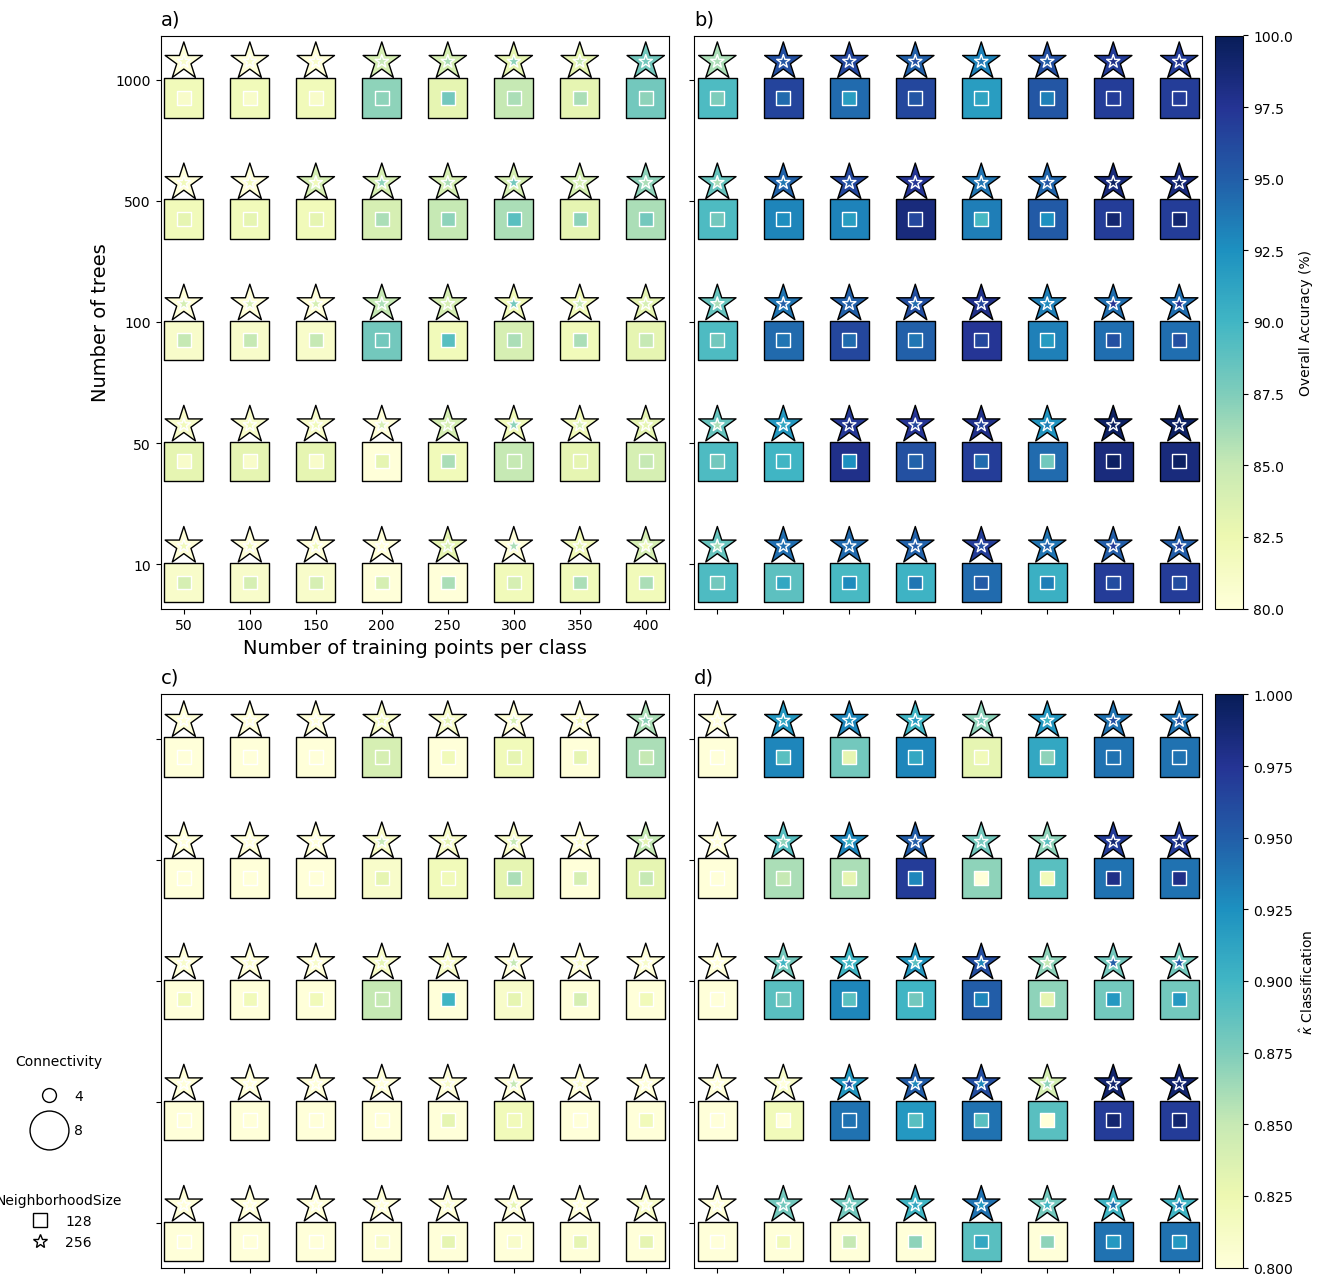

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import os


base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

fn_csv = os.path.join('..', 'parameter_search_results.csv')

save_path = os.path.join(base_dir, "Figure2.png")

df_parameters = pd.read_csv(fn_csv)

# re-map values for plotting purposes
df_parameters['num_trees'] = df_parameters['num_trees'].replace({10: 0, 50: 1, 100: 2, 500: 3, 1000: 4})
df_parameters['kappa_multi'] *= 100
df_parameters['kappa_binary'] *= 100

fig, axes = plt.subplots(2, 2, figsize=(16, 16), gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

#cbar_ax_accuracy = fig.add_axes([0.91, 0.53, 0.02, 0.35])
#cbar_ax_kappa = fig.add_axes([0.91, 0.13, 0.02, 0.35])

kappa_norm = mcolors.Normalize(vmin=0.80, vmax=1.00)
kappa_col = mcolorizer.Colorizer(cmap='YlGnBu', norm=kappa_norm)

acc_norm = mcolors.Normalize(vmin=80, vmax=100)
acc_col = mcolorizer.Colorizer(cmap='YlGnBu', norm=acc_norm)

neigh_dict = {128: 's',
              256: '*'}

offset = {128: -0.15,
          256: 0.15}

size_dict = {4: 100,
             8: 800}

edge_dict = {4: 'w',
             8: 'k'}

measures = ['overall_multi', 'overall_binary', 'kappa_multi', 'kappa_binary']

# plot is x: points_per_class, y: num_trees, marker: connectivity, neighborhood: fill, color: accuracy measure
# markers:
for meas, ax in zip(measures, axes.flatten()):
    for (conn, neigh), df in df_parameters.groupby(['connectivity', 'neighborhood_size']):
        ax.scatter(
            x=df['points_per_class'],
            y=df['num_trees'] + offset[neigh],
            c=df[meas],
            s=size_dict[conn],
            edgecolor=edge_dict[conn],
            marker=neigh_dict[neigh],
            cmap='YlGnBu',
            vmin=80,
            vmax=100,
            zorder=1/conn
        )
    ax.set_xticks(range(50, 401, 50))
    ax.set_yticks(range(0, 5))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

fig.colorbar(mcolorizer.ColorizingArtist(acc_col), ax=axes[0, :], pad=0.01, label='Overall Accuracy (%)')
fig.colorbar(mcolorizer.ColorizingArtist(kappa_col), ax=axes[1, :], pad=0.01, label=r'$\hat{\kappa}$ Classification')

axes[0, 0].set_xticklabels(range(50, 401, 50))
axes[0, 0].set_yticklabels([10, 50, 100, 500, 1000])

axes[0, 0].set_ylabel('Number of trees', fontsize=14)
axes[0, 0].set_xlabel('Number of training points per class', fontsize=14)

#axes[0, 0].set_title('Multi-class')
#axes[0, 1].set_title('Binary Classification')

small = mlines.Line2D([], [], color='k', linestyle='none', marker='o', markersize=10, markerfacecolor='none', label='4')
large = mlines.Line2D([], [], color='k', linestyle='none', marker='o', markersize=28, markerfacecolor='none', label='8')

square = mlines.Line2D([], [], color='k', linestyle='none', marker='s', markersize=10, markerfacecolor='none', label='128')
star = mlines.Line2D([], [], color='k', linestyle='none', marker='*', markersize=10, markerfacecolor='none', label='256')

#red_patch = mpatches.Patch(color='red', label='The red data')

nsize_leg = axes[1, 0].legend(title='NeighborhoodSize', handles=[square, star], loc='lower center', bbox_to_anchor=(-0.2, 0.01), frameon=False)
axes[1, 0].add_artist(nsize_leg)

conn_leg = axes[1, 0].legend(title='Connectivity', handles=[small, large], labelspacing=1.5,
                             loc='center', bbox_to_anchor=(-0.2, 0.3), frameon=False)

for lab, ax in zip('abcd', axes.flatten()):
    ax.annotate(f"{lab})", (0, 1.02), xycoords='axes fraction', fontsize=14)

fig.savefig('Figure2.png', dpi=200, bbox_inches='tight', bbox_extra_artists=[nsize_leg])